# Day 05 — Train/Test Split နှင့် Model Evaluation

Day 04 မှာ data အားလုံးနဲ့ model ကို train လုပ်ခဲ့ပါတယ်။ ဒါပေမယ့် Model က မမြင်ဖူးသေးတဲ့ data ကို ကောင်းကောင်းခန့်မှန်းနိုင်မနိုင် စစ်ဖို့ Dataset ကို နှစ်ပိုင်းခွဲရပါတယ်။

- **Training Data** — Model သင်ယူဖို့
- **Testing Data** — Model ကို စာမေးပွဲစစ်ဖို့

## 1. Libraries Import

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

## 2. Dataset တည်ဆောက်ခြင်း

Day 04 ထက် data ပိုများအောင် အသုံးပြုပါမယ်။

In [2]:
data = {
    "advertising": [
        100, 150, 200, 250,
        300, 350, 400, 450,
        500, 550, 600, 650
    ],
    "sales": [
        1.2, 1.5, 1.9, 2.1,
        2.5, 2.8, 3.2, 3.4,
        3.9, 4.1, 4.5, 4.9
    ]
}

df = pd.DataFrame(data)

df

,advertising,sales
0,100,1.2
1,150,1.5
2,200,1.9
3,250,2.1
4,300,2.5
5,350,2.8
6,400,3.2
7,450,3.4
8,500,3.9
9,550,4.1


## 3. Feature နှင့် Target ခွဲခြင်း

In [3]:
X = df[["advertising"]]
y = df["sales"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (12, 1)
y shape: (12,)


`X` ကို double bracket `[[ ]]` သုံးထားတာ သတိထားပါ။

```python
df[["advertising"]]
```

ဒီလိုရေးခြင်းကြောင့် `X` က `(12, 1)` ပုံစံရှိတဲ့ 2D data ဖြစ်လာပါတယ်။

## 4. Training နှင့် Testing Data ခွဲခြင်း

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42
)

ဒီနေရာမှာ—

- `test_size=0.25` — Data 25% ကို testing အဖြစ်ထားမယ်
- ကျန် 75% ကို training အဖြစ်သုံးမယ်
- `random_state=42` — Program ပြန် run တိုင်း data ခွဲပုံတူစေမယ်

အရွယ်အစားစစ်ကြည့်ပါ။

In [5]:
print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)

print("Training targets:", y_train.shape)
print("Testing targets:", y_test.shape)

Training features: (9, 1)
Testing features: (3, 1)
Training targets: (9,)
Testing targets: (3,)


မျှော်မှန်းရလဒ်—

```
Training features: (9, 1)
Testing features: (3, 1)
Training targets: (9,)
Testing targets: (3,)
```

## 5. Model Training

In [6]:
model = LinearRegression()

model.fit(X_train, y_train)

print("Model training completed.")

Model training completed.


အရေးကြီးတဲ့အချက်က Model ကို `X_train` နဲ့ `y_train` သာ ပေးထားတာပါ။ Testing Data ကို Model က မမြင်ဖူးသေးပါဘူး။

## 6. Testing Data ကို ခန့်မှန်းခြင်း

In [7]:
y_pred = model.predict(X_test)

print("Actual sales:")
print(y_test.to_numpy())

print("Predicted sales:")
print(y_pred)

Actual sales:
[4.5 4.1 1.2]
Predicted sales:
[4.52527933 4.18743017 1.14678771]


Actual နဲ့ Predicted တန်ဖိုးတွေကို DataFrame နဲ့ နှိုင်းယှဉ်ကြည့်နိုင်ပါတယ်။

In [8]:
results = pd.DataFrame({
    "advertising": X_test["advertising"],
    "actual_sales": y_test,
    "predicted_sales": y_pred
})

results["difference"] = (
    results["actual_sales"] -
    results["predicted_sales"]
)

results

,advertising,actual_sales,predicted_sales,difference
10,600,4.5,4.525279,-0.025279
9,550,4.1,4.187430,-0.087430
0,100,1.2,1.146788,0.053212


## 7. Model Evaluation

Model အမှားပမာဏနဲ့ အရည်အသွေးကို metric သုံးမျိုးနဲ့ စစ်ဆေးပါမယ်။

In [9]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae:.4f}")
print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R² Score: {r2:.4f}")

MAE: 0.0553
MSE: 0.0037
RMSE: 0.0609
R² Score: 0.9983


### Metrics တွေရဲ့အဓိပ္ပာယ်

#### MAE — Mean Absolute Error

```
Actual နဲ့ Prediction ကြား ပျမ်းမျှအမှား
```

ဥပမာ `MAE = 0.10` ဆိုရင် Sales ခန့်မှန်းချက်ဟာ ပျမ်းမျှ `0.10 သန်း` လောက် မှားနိုင်တယ်လို့ နားလည်နိုင်ပါတယ်။

MAE က `0` နီးလေ ကောင်းလေပါ။

#### MSE — Mean Squared Error

အမှားတန်ဖိုးတွေကို square root လုပ်ပြီး ပျမ်းမျှယူတာပါ။ ကြီးမားတဲ့အမှားတွေကို ပိုမိုအရေးပေးပါတယ်။

MSE ကလည်း `0` နီးလေ ကောင်းလေပါ။

#### RMSE — Root Mean Squared Error

MSE ကို square root ပြန်ယူထားတာဖြစ်ပြီး Sales နဲ့ unit တူသွားပါတယ်။ ဒါကြောင့် လက်တွေ့နားလည်ရ ပိုလွယ်ပါတယ်။

#### R² Score

Model က Data Pattern ကို ဘယ်လောက်ကောင်းကောင်း ရှင်းပြနိုင်သလဲဆိုတာ ပြပါတယ်။

| R² Score | အဓိပ္ပာယ် |
|---:|---|
| `1.00` | အလွန်ပြည့်စုံ |
| `0.90` အထက် | အလွန်ကောင်း |
| `0.70 – 0.90` | ကောင်း |
| `0.50 – 0.70` | အသင့်အတင့် |
| `0.50` အောက် | Model/Data ပြန်စစ်ရန် |
| Negative | Baseline ထက်တောင် ခန့်မှန်းမှုညံ့ |

လက်တွေ့ Project တွေမှာ `R²` တစ်ခုတည်းကြည့်ပြီး မဆုံးဖြတ်သင့်ပါဘူး။ `MAE`, `RMSE` နဲ့ business context ကိုပါ တွဲကြည့်ရပါတယ်။

## 8. Graph ဖြင့် Actual နှင့် Prediction နှိုင်းယှဉ်ခြင်း

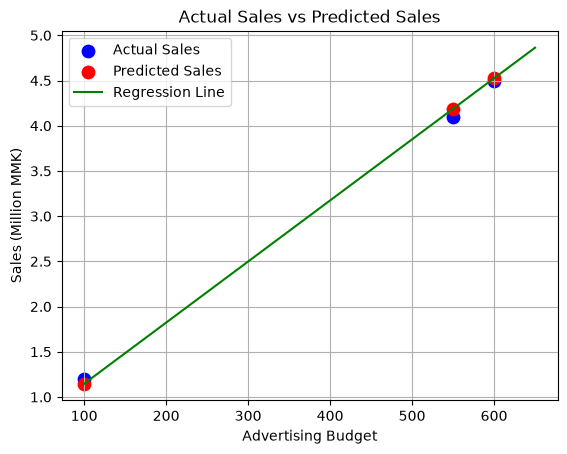

In [10]:
plt.scatter(
    X_test["advertising"],
    y_test,
    color="blue",
    s=80,
    label="Actual Sales"
)

plt.scatter(
    X_test["advertising"],
    y_pred,
    color="red",
    s=80,
    label="Predicted Sales"
)

plt.plot(
    df["advertising"],
    model.predict(df[["advertising"]]),
    color="green",
    label="Regression Line"
)

plt.xlabel("Advertising Budget")
plt.ylabel("Sales (Million MMK)")
plt.title("Actual Sales vs Predicted Sales")
plt.legend()
plt.grid(True)
plt.show()

## Day 05 လေ့ကျင့်ခန်း

Model ကိုအသုံးပြုပစီ Advertising Budget အသစ်တွေ ခန့်မှန်းပါ။

In [11]:
new_budgets = pd.DataFrame({
    "advertising": [175, 325, 475, 700]
})

new_predictions = model.predict(new_budgets)

prediction_results = new_budgets.copy()
prediction_results["predicted_sales"] = new_predictions

prediction_results["predicted_sales"] = (
    prediction_results["predicted_sales"].round(2)
)

prediction_results

,advertising,predicted_sales
0,175,1.65
1,325,2.67
2,475,3.68
3,700,5.20
